# Transformation to C Code (Simple)

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_jax.fvm.solver_jax import Settings
from zoomy_core.model.models.shallow_water import ShallowWaterEquations

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct
from zoomy_core.transformation.to_c import CppModel, CppNumerics
import zoomy_core.mesh.mesh as petscMesh
import zoomy_core.misc.misc as misc


## Model definition

In [2]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="wall"),
        BC.Wall(tag="inflow"),
        BC.Wall(tag="outflow"),
    ]
)

def custom_ic(x):
    Q = np.zeros(3, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model = ShallowWaterEquations(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
)

# the mesh is necessary to connect the boundary conditions to the mesh tags
main_dir = misc.get_main_directory()
mesh = petscMesh.Mesh.from_gmsh(
    os.path.join(main_dir, "meshes/channel_quad_2d/mesh.msh")
)

## Sympy Model

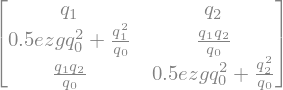

In [3]:
model.flux()

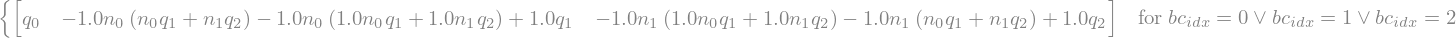

In [4]:
model.print_boundary_conditions()

## Code transformation

In [5]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5", clean_directory=True, snapshots=2))
CppModel.write_code(model, settings)

'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H'

In [6]:
from zoomy_core.fvm.symbolic_numerics import Rusanov

In [7]:
numerics = Rusanov(model)

In [8]:
CppNumerics.write_code(numerics, settings)

ValueError: Index (2,) out of border

## Check the output

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.c_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <algorithm>
#include <vector>
#include <string>

template <typename T>
struct Model {

    // --- Constants ---
    static constexpr int n_dof_q    = 3;
    static constexpr int n_dof_qaux = 2;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 3;

    // --- Helpers ---
    static const std::vector<std::string> get_boundary_tags() { return { "inflow", "outflow", "wall" }; }

    // --- Kernels ---

    static inline void flux(
        const T* Q,
        const T* Qaux,
        T* res)
    {
    T t0 = 0.5*1.0*9.81*std::pow(Q[0], 2);
    T t1 = (1.0 / std::pow(Q[0], 1));
    T t2 = Q[1]*Q[2]*t1;
    res[0] = Q[1];
    res[1] = Q[2];
    res[2] = std::pow(Q[1], 2)*t1 + t0;
    res[3] = t2;
    res[4] = t2;
    res[5] = std::pow(Q[2], 2)*t1 + t0;
    }


    static inline void dflux(
        const T* Q,
        const T* Qaux,
        T* res)
    {
    res[0] = 0;
    res[1] = 0;
    res[2] = 0;
    res[3] = 0;
    re